Loading + preprocessing images:
  z=0.53 m  file='messung 53cm.tiff'
  z=2.00 m  file='messung 200 cm.tiff'
  z=3.50 m  file='messung 350cm.tiff'
  z=5.00 m  file='messung 500cm.tiff'
  z=7.50 m  file='messung 750cm.tiff'
Searching best fit with J=2 modes
Random trials: 80, local iters: 80
  trial    8/80: best mean NRMSE=0.10868  weights=[0.00651528 0.99348472]
  trial   16/80: best mean NRMSE=0.10577  weights=[0.00651528 0.99348472]
  trial   24/80: best mean NRMSE=0.10577  weights=[0.00651528 0.99348472]
  trial   32/80: best mean NRMSE=0.10577  weights=[0.00651528 0.99348472]
  trial   40/80: best mean NRMSE=0.10577  weights=[0.00651528 0.99348472]
  trial   48/80: best mean NRMSE=0.10577  weights=[0.00651528 0.99348472]
  trial   56/80: best mean NRMSE=0.10383  weights=[0.00651529 0.99348471]
  trial   64/80: best mean NRMSE=0.10383  weights=[0.00651529 0.99348471]
  trial   72/80: best mean NRMSE=0.10383  weights=[0.00651529 0.99348471]
  trial   80/80: best mean NRMSE=0.10383  w

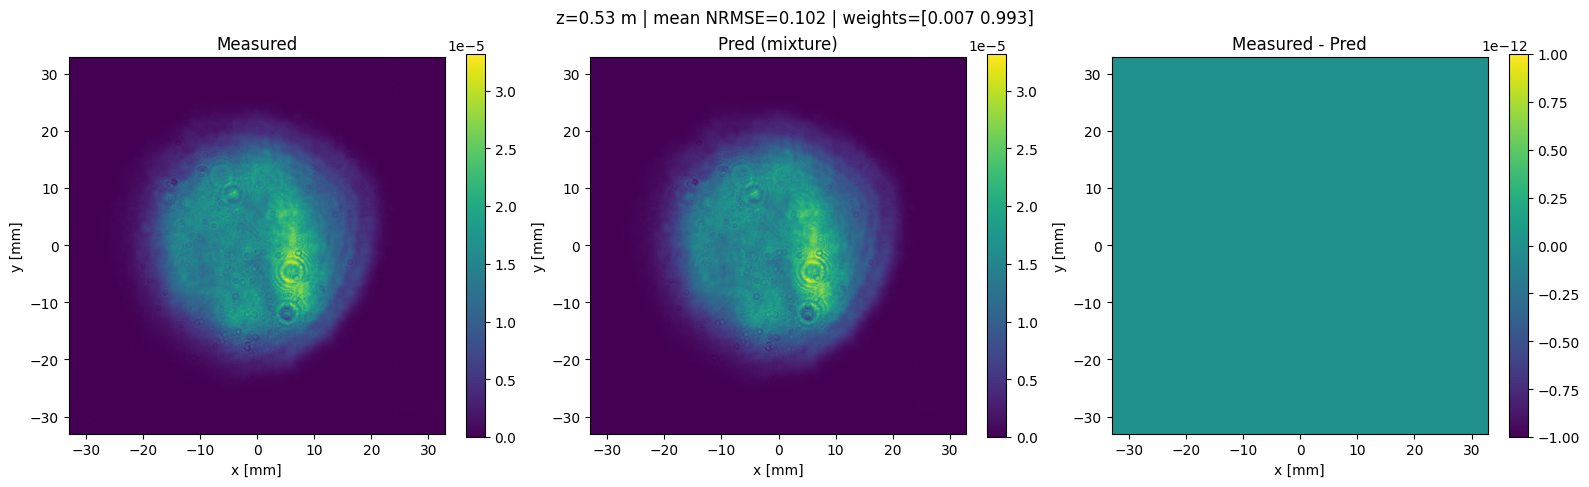

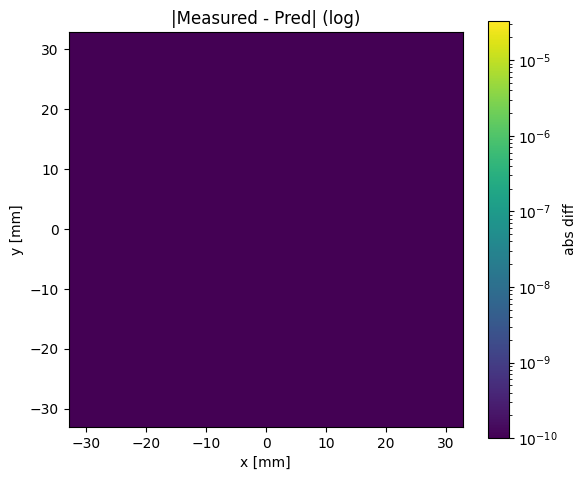

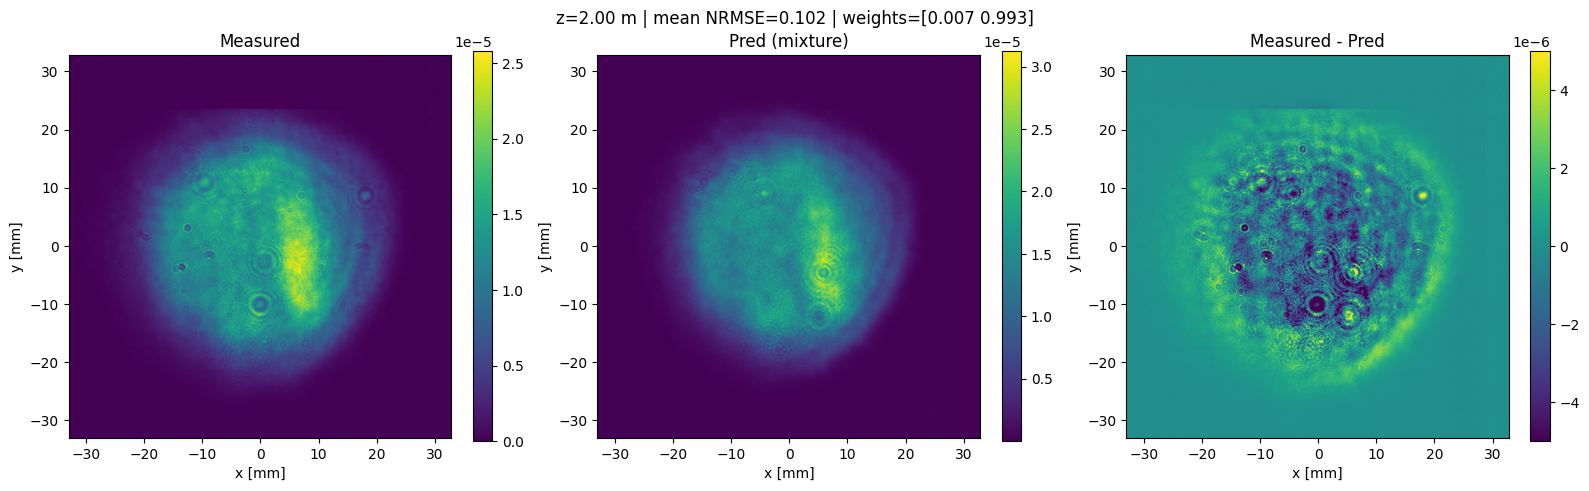

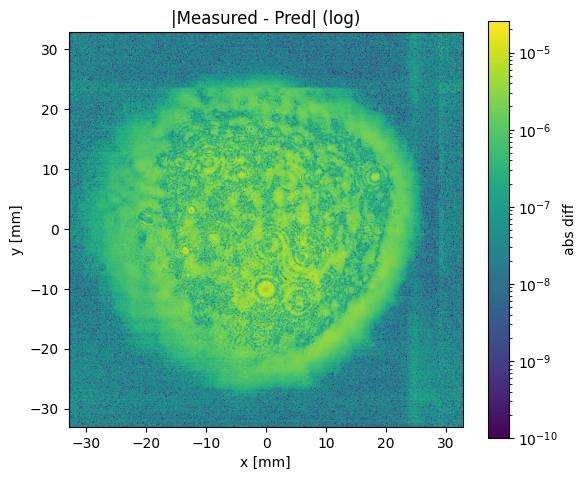

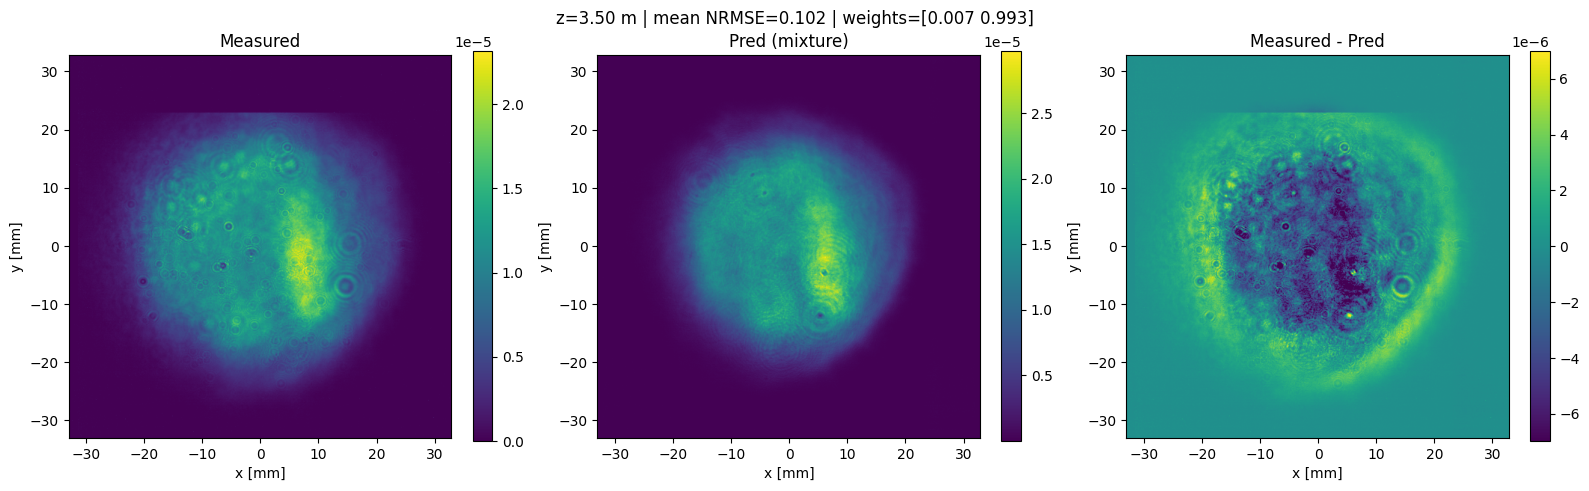

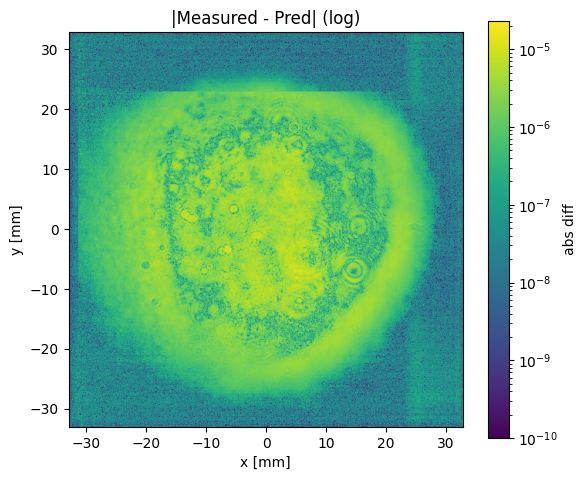

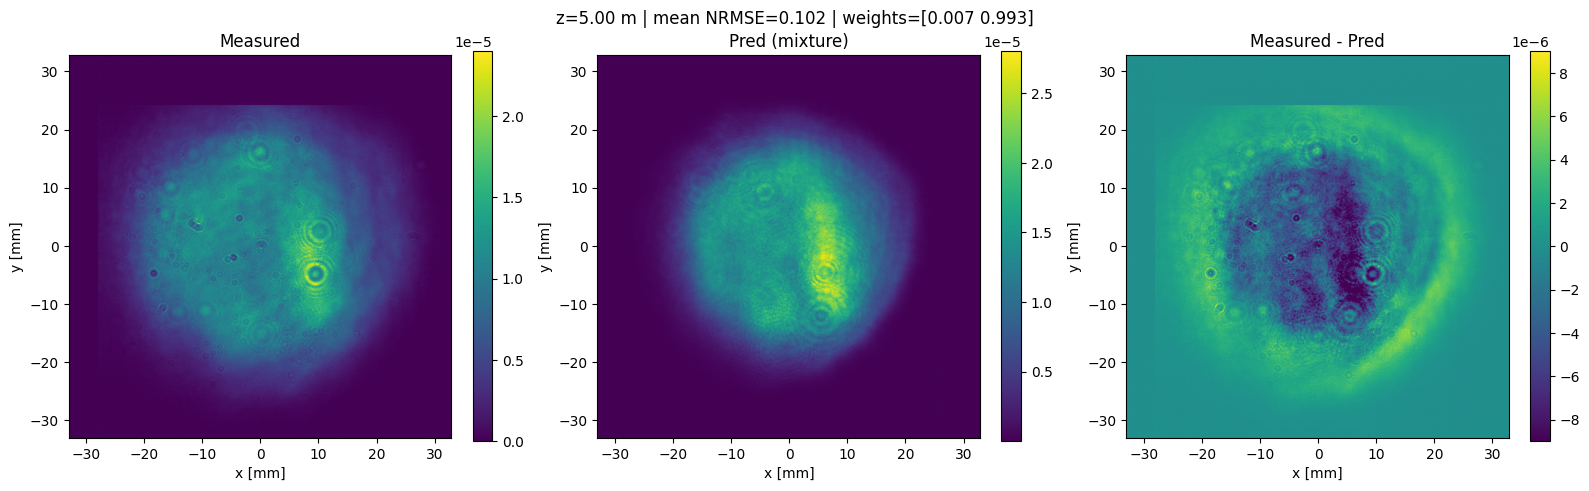

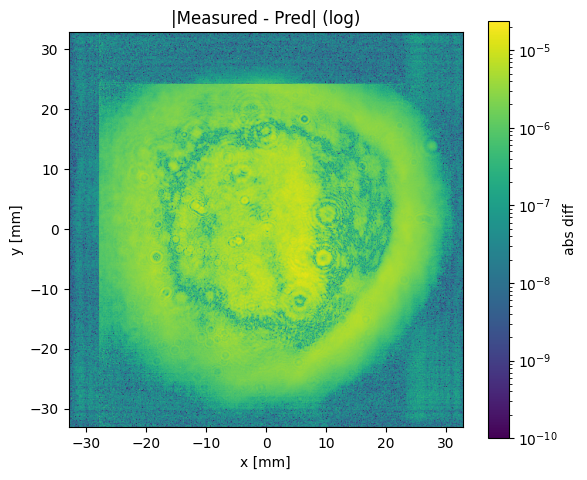

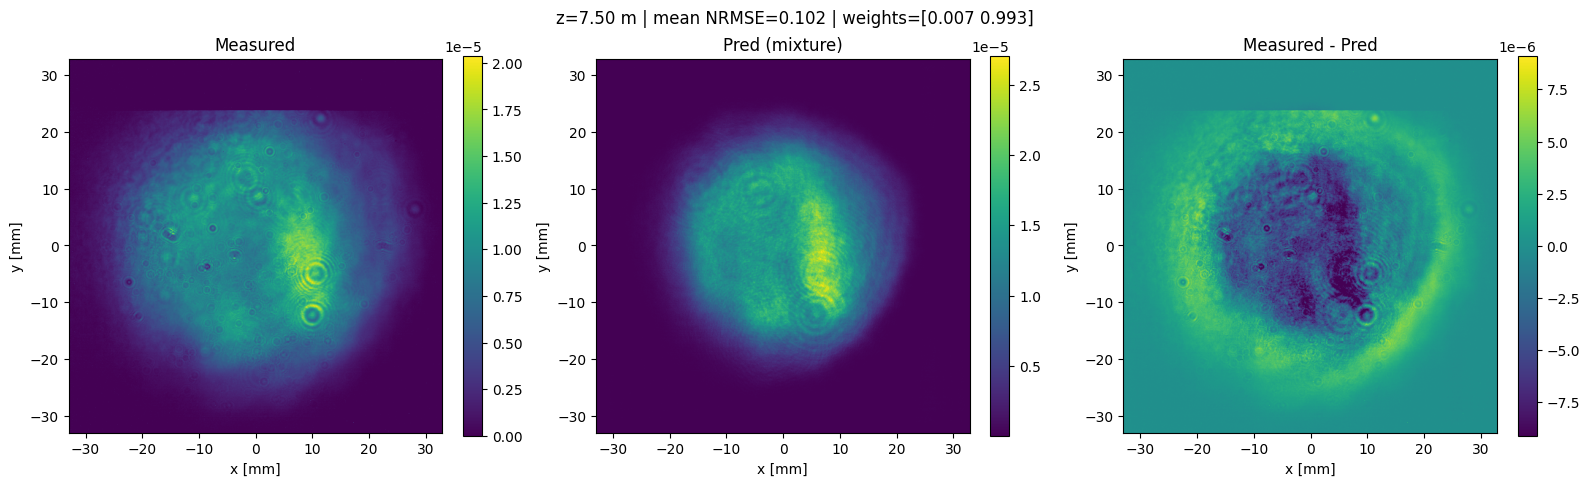

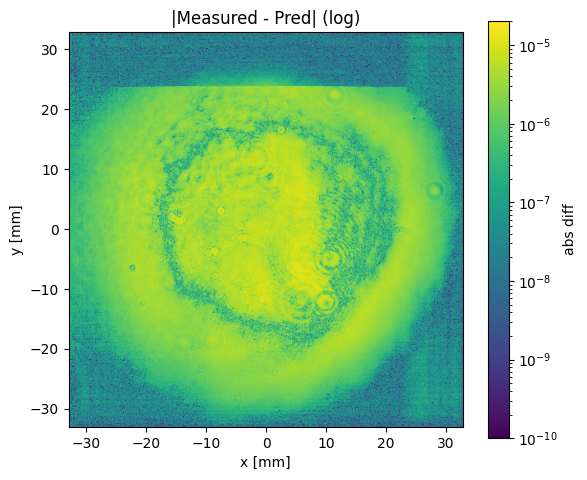

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ==============================================================
# 0) USER SETTINGS
# ==============================================================

PLANES = [
    (0.53, "messung 53cm.tiff"),
    (2.00, "messung 200 cm.tiff"),
    (3.50, "messung 350cm.tiff"),
    (5.00, "messung 500cm.tiff"),
]

LAM = 800e-9

# Grid (schneller: 512; besser: 1024)
N = 512
L = 0.066          # [m] muss zur Kamera-FOV passen!
dx = L / N
x = (np.arange(N) - N/2) * dx
X, Y = np.meshgrid(x, x)

# Preprocess
CENTER = True
SUBTRACT_BG = True
EDGE_FRAC = 0.03
CENTER_THRESH_REL = 0.2
NORM_MODE = "energy"   # "energy" (robust) oder "peak"

# Fit region
BEAM_MASK_REL = 0.05   # nur im Beam fitten (robust)

# Variant A model
J_MODES = 2            # 2 = core+halo, 3..4 möglich, aber langsamer/overfit riskanter

# Phase model per mode j:
# phi = correlated_screen(phi_rms, l_corr) + tilt(tx,ty) + defocus(a_defocus)
# Ranges für Suche:
RANGE_PHI_RMS = (0.0, 2.5)        # rad
RANGE_LCORR_MM = (0.5, 10.0)      # mm
RANGE_TILT_URAD = (-80.0, 80.0)   # urad
RANGE_DEFOCUS_RAD = (-6.0, 6.0)   # rad amplitude (Zernike-like defocus)

# Optimization budget
RANDOM_TRIALS = 80        # grob-Suche (je größer, desto besser)
LOCAL_ITERS = 80          # lokale Verfeinerung
LOCAL_SIGMA = np.array([0.15, 0.15, 10.0, 10.0, 0.6])  # std für [phi_rms, log10(lcorr), tilt_x, tilt_y, defocus]

# Weight solver
W_STEPS = 300
W_LR = 0.4
W_L2 = 1e-6

SEED = 3

# ==============================================================
# 1) IO + Preprocessing
# ==============================================================

def load_tiff_gray(filename: str) -> np.ndarray:
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")

    try:
        import tifffile
        img = tifffile.imread(filename)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(filename))

    img = np.asarray(img)
    if img.ndim == 3:
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            img = img[0]
    return img.astype(np.float64)

def resample_bilinear(img, new_h, new_w):
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

def center_by_mask_centroid(I, thresh_rel=0.2):
    I = np.asarray(I, float)
    if I.max() <= 0:
        return I
    t = thresh_rel * I.max()
    m = I > t
    if not np.any(m):
        return I

    yy, xx = np.indices(I.shape)
    w = I[m]
    cx = (xx[m] * w).sum() / (w.sum() + 1e-12)
    cy = (yy[m] * w).sum() / (w.sum() + 1e-12)

    sx = int(round(I.shape[1] / 2 - cx))
    sy = int(round(I.shape[0] / 2 - cy))
    return np.roll(np.roll(I, sy, axis=0), sx, axis=1)

def subtract_background_border(I, edge_frac=0.03):
    edge = max(10, int(edge_frac * min(I.shape)))
    border = np.concatenate([
        I[:edge, :].ravel(),
        I[-edge:, :].ravel(),
        I[:, :edge].ravel(),
        I[:, -edge:].ravel(),
    ])
    bg = np.median(border)
    I = I - bg
    I[I < 0] = 0.0
    return I

def normalize_intensity(I, mode="energy"):
    if mode == "peak":
        return I / (I.max() + 1e-12)
    if mode == "energy":
        return I / (I.sum() + 1e-12)
    raise ValueError("mode must be 'peak' or 'energy'")

def preprocess_intensity(I):
    I = I.astype(np.float64)
    if SUBTRACT_BG:
        I = subtract_background_border(I, edge_frac=EDGE_FRAC)
    if CENTER:
        I = center_by_mask_centroid(I, thresh_rel=CENTER_THRESH_REL)
    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)
    I = normalize_intensity(I, mode=NORM_MODE)
    return I

def beam_mask(I, rel=0.05):
    return I >= (rel * (I.max() + 1e-12))

# ==============================================================
# 2) ASM propagation (precompute kz)
# ==============================================================

k0 = 2*np.pi / LAM

def precompute_kz():
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k0**2 - kx**2 - ky**2 + 0j)
    return kz

KZ = precompute_kz()

def H_of_dz(dz):
    return np.exp(1j * KZ * dz)

def propagate_with_H(U, H):
    return np.fft.ifft2(np.fft.fft2(U) * H)

# ==============================================================
# 3) Phase model: correlated screen + tilt + defocus
# ==============================================================

def correlated_phase_screen(rng, phi_rms, l_corr_m):
    """White noise -> Gaussian lowpass in k-space -> normalize RMS."""
    if phi_rms <= 0:
        return np.zeros((N, N), dtype=np.float64)

    w = rng.standard_normal((N, N))

    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    f2 = FX**2 + FY**2

    # l_corr ~ 1/(2*pi*sigma_f)
    sigma_f = 1.0 / (2*np.pi * max(l_corr_m, 1e-12))
    G = np.exp(-0.5 * (f2 / (sigma_f**2 + 1e-30)))

    ph = np.real(np.fft.ifft2(np.fft.fft2(w) * G))
    ph -= ph.mean()
    ph *= (phi_rms / (np.std(ph) + 1e-12))
    return ph

def tilt_phase(tilt_x_urad, tilt_y_urad):
    tx = tilt_x_urad * 1e-6
    ty = tilt_y_urad * 1e-6
    return k0 * (tx * X + ty * Y)

def defocus_phase(a_rad):
    """
    Simple Zernike-like defocus on normalized radius r in [0,1].
    phi = a*(2r^2-1). a in radians.
    """
    R = (L/2)
    r2 = (X**2 + Y**2) / (R**2 + 1e-30)
    r2 = np.clip(r2, 0.0, 1.0)
    return a_rad * (2.0*r2 - 1.0)

def make_phase_for_mode(mode_seed, params):
    """
    params = [phi_rms, lcorr_mm, tilt_x_urad, tilt_y_urad, defocus_rad]
    returns phi(x,y)
    """
    phi_rms, lc_mm, tx, ty, a_def = params
    rng = np.random.default_rng(mode_seed)
    ph = correlated_phase_screen(rng, phi_rms=phi_rms, l_corr_m=lc_mm*1e-3)
    ph += tilt_phase(tx, ty)
    ph += defocus_phase(a_def)
    return ph

# ==============================================================
# 4) Loss + weight fit (NNLS via projected GD)
# ==============================================================

def solve_weights_nnls(I_modes_planes, I_meas, masks, steps=300, lr=0.4, l2=1e-6):
    """
    I_modes_planes: list length P, each is array [J, N, N] intensity of each mode at plane p
    Find w>=0, sum w=1 minimizing sum_p mean((sum_j w_j I_jp - I_meas_p)^2 over mask)
    """
    P = len(I_meas)
    J = I_modes_planes[0].shape[0]
    rng = np.random.default_rng(SEED + 123)
    w = rng.random(J).astype(np.float64)
    w /= (w.sum() + 1e-12)

    # flatten masked pixels
    T = []
    y = []
    for p in range(P):
        mp = masks[p]
        T.append(I_modes_planes[p][:, mp].reshape(J, -1))  # [J,K]
        y.append(I_meas[p][mp].ravel())                    # [K]

    for _ in range(steps):
        grad = np.zeros_like(w)
        for p in range(P):
            Tp = T[p]
            yp = y[p]
            pred = w @ Tp
            diff = pred - yp
            grad += (2.0/(Tp.shape[1] + 1e-12)) * (Tp @ diff)

        grad += 2*l2*w
        w = w - lr*grad
        w[w < 0] = 0.0
        s = w.sum()
        if s > 0:
            w /= s

    return w

def predict_mixture(I_modes_planes, w):
    P = len(I_modes_planes)
    I_pred = []
    for p in range(P):
        I = np.tensordot(w, I_modes_planes[p], axes=(0, 0))  # [N,N]
        I = normalize_intensity(I, mode=NORM_MODE)
        I_pred.append(I)
    return I_pred

def nrmse(I_pred, I_meas, mask):
    a = I_meas[mask].ravel()
    b = I_pred[mask].ravel()
    rmse = np.sqrt(np.mean((a-b)**2))
    denom = (a.max() - a.min()) + 1e-12
    return rmse / denom

def total_loss(I_pred, I_meas, masks):
    errs = [nrmse(I_pred[p], I_meas[p], masks[p]) for p in range(len(I_meas))]
    return float(np.mean(errs)), errs

# ==============================================================
# 5) Visualization
# ==============================================================

def compare_plane(I_meas, I_pred, title="", eps=1e-10):
    x_mm = x*1e3
    extent = [x_mm.min(), x_mm.max(), x_mm.min(), x_mm.max()]
    diff = I_meas - I_pred
    vmax = np.percentile(np.abs(diff), 99.5) + 1e-12

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8))
    im0 = axs[0].imshow(I_meas, origin="lower", extent=extent, aspect="equal")
    axs[0].set_title("Measured")
    plt.colorbar(im0, ax=axs[0], fraction=0.046)

    im1 = axs[1].imshow(I_pred, origin="lower", extent=extent, aspect="equal")
    axs[1].set_title("Pred (mixture)")
    plt.colorbar(im1, ax=axs[1], fraction=0.046)

    im2 = axs[2].imshow(diff, origin="lower", extent=extent, aspect="equal", vmin=-vmax, vmax=vmax)
    axs[2].set_title("Measured - Pred")
    plt.colorbar(im2, ax=axs[2], fraction=0.046)

    for ax in axs:
        ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(np.maximum(np.abs(diff), eps), origin="lower", extent=extent, aspect="equal",
               norm=LogNorm(vmin=eps, vmax=max(1e-6, np.max(I_meas))))
    plt.title("|Measured - Pred| (log)")
    plt.xlabel("x [mm]"); plt.ylabel("y [mm]")
    plt.colorbar(label="abs diff")
    plt.tight_layout()
    plt.show()

# ==============================================================
# 6) Build mode intensities for given params set
# ==============================================================

def simulate_modes_intensities(I_ref, dz_list, params_list):
    """
    params_list: list length J of params for each mode
    Returns list length P where each entry is array [J,N,N] intensities.
    """
    A0 = np.sqrt(np.maximum(I_ref, 0.0)).astype(np.float64)
    A0 = A0.astype(np.complex128)

    H_list = [H_of_dz(dz) for dz in dz_list]
    P = len(dz_list)
    J = len(params_list)

    I_modes_planes = [np.zeros((J, N, N), dtype=np.float64) for _ in range(P)]

    for j in range(J):
        phi = make_phase_for_mode(mode_seed=SEED + 1000 + j*17, params=params_list[j])
        U0 = A0 * np.exp(1j * phi)

        for p, H in enumerate(H_list):
            Up = propagate_with_H(U0, H)
            I = (np.abs(Up)**2).real
            I = normalize_intensity(I, mode=NORM_MODE)
            I_modes_planes[p][j] = I

    return I_modes_planes

# ==============================================================
# 7) Optimization: random search + local refinement
# ==============================================================
def predict_at_planes(I_ref, z_positions, params_list, weights, z0=None):
    """
    Simuliert Intensitäten an beliebigen z-Positionen mit gegebenen params_list + weights.
    I_ref: Referenzintensität am z0 (Amplitude sqrt(I_ref))
    z_positions: Liste absoluter z (in m)
    z0: Referenzebene (wenn None: z_positions[0])
    """
    if z0 is None:
        z0 = z_positions[0]
    dz_list = [z - z0 for z in z_positions]
    I_modes_planes = simulate_modes_intensities(I_ref=I_ref, dz_list=dz_list, params_list=params_list)
    I_pred = predict_mixture(I_modes_planes, weights)
    return I_pred


def sample_random_params(rng):
    phi_rms = rng.uniform(*RANGE_PHI_RMS)
    lc_mm = rng.uniform(*RANGE_LCORR_MM)
    tx = rng.uniform(*RANGE_TILT_URAD)
    ty = rng.uniform(*RANGE_TILT_URAD)
    a_def = rng.uniform(*RANGE_DEFOCUS_RAD)
    return np.array([phi_rms, lc_mm, tx, ty, a_def], dtype=np.float64)

def clamp_params(p):
    p = p.copy()
    p[0] = np.clip(p[0], *RANGE_PHI_RMS)
    p[1] = np.clip(p[1], *RANGE_LCORR_MM)
    p[2] = np.clip(p[2], *RANGE_TILT_URAD)
    p[3] = np.clip(p[3], *RANGE_TILT_URAD)
    p[4] = np.clip(p[4], *RANGE_DEFOCUS_RAD)
    return p

def best_fit_variantA(I_meas, z_positions):
    rng = np.random.default_rng(SEED)
    z0 = z_positions[0]
    dz_list = [z - z0 for z in z_positions]

    masks = [beam_mask(I, rel=BEAM_MASK_REL) for I in I_meas]

    # --- init random ---
    best = None

    print(f"Searching best fit with J={J_MODES} modes")
    print(f"Random trials: {RANDOM_TRIALS}, local iters: {LOCAL_ITERS}")

    for t in range(RANDOM_TRIALS):
        params_list = [sample_random_params(rng) for _ in range(J_MODES)]

        I_modes_planes = simulate_modes_intensities(I_ref=I_meas[0], dz_list=dz_list, params_list=params_list)
        w = solve_weights_nnls(I_modes_planes, I_meas, masks, steps=W_STEPS, lr=W_LR, l2=W_L2)
        I_pred = predict_mixture(I_modes_planes, w)
        loss, per_plane = total_loss(I_pred, I_meas, masks)

        if best is None or loss < best["loss"]:
            best = {
                "loss": loss,
                "per_plane": per_plane,
                "params_list": [p.copy() for p in params_list],
                "weights": w.copy(),
                "I_pred": I_pred,
            }

        if (t+1) % max(1, RANDOM_TRIALS//10) == 0:
            print(f"  trial {t+1:4d}/{RANDOM_TRIALS}: best mean NRMSE={best['loss']:.5g}  weights={best['weights']}")

    # --- local refinement (stochastic hill-climb) ---
    # We perturb each mode params and accept if loss improves.
    params_list = [p.copy() for p in best["params_list"]]
    w_best = best["weights"].copy()
    loss_best = best["loss"]

    # Use log space for lcorr for stable moves
    def pack_for_move(p):
        q = p.copy()
        q[1] = np.log10(q[1])
        return q
    def unpack_after_move(q):
        p = q.copy()
        p[1] = 10**p[1]
        return clamp_params(p)

    packed = [pack_for_move(p) for p in params_list]

    for it in range(LOCAL_ITERS):
        # pick a random mode to tweak
        j = rng.integers(0, J_MODES)
        cand = [q.copy() for q in packed]

        step = rng.normal(0.0, LOCAL_SIGMA)
        cand[j] = cand[j] + step

        # clamp lcorr in log domain by clamping in linear after unpack
        params_cand = [unpack_after_move(q) for q in cand]

        I_modes_planes = simulate_modes_intensities(I_ref=I_meas[0], dz_list=dz_list, params_list=params_cand)
        w = solve_weights_nnls(I_modes_planes, I_meas, masks, steps=W_STEPS, lr=W_LR, l2=W_L2)
        I_pred = predict_mixture(I_modes_planes, w)
        loss, per_plane = total_loss(I_pred, I_meas, masks)

        if loss < loss_best:
            loss_best = loss
            w_best = w.copy()
            packed = cand
            best = {
                "loss": loss,
                "per_plane": per_plane,
                "params_list": [p.copy() for p in params_cand],
                "weights": w.copy(),
                "I_pred": I_pred,
            }

        if (it+1) % max(1, LOCAL_ITERS//10) == 0:
            print(f"  local {it+1:4d}/{LOCAL_ITERS}: best mean NRMSE={best['loss']:.5g}  weights={best['weights']}")

    return best

# ==============================================================
# 8) MAIN
# ==============================================================

if __name__ == "__main__":
    # -------------------------
    # Load + preprocess TRAIN
    # -------------------------
    z_train = [z for z, _ in PLANES_TRAIN]
    print("Loading + preprocessing TRAIN images:")
    I_train = []
    for z, fn in PLANES_TRAIN:
        print(f"  TRAIN z={z:.2f} m  file='{fn}'")
        I_train.append(preprocess_intensity(load_tiff_gray(fn)))

    # -------------------------
    # Load + preprocess TEST
    # -------------------------
    z_test, fn_test = PLANE_TEST
    print("\nLoading + preprocessing TEST image:")
    print(f"  TEST  z={z_test:.2f} m  file='{fn_test}'")
    I_test = preprocess_intensity(load_tiff_gray(fn_test))

    # -------------------------
    # FIT nur auf TRAIN
    # -------------------------
    best = best_fit_variantA(I_train, z_train)

    print("\n=== BEST FIT (TRAIN only) ===")
    print(f"Mean TRAIN NRMSE: {best['loss']:.6g}")
    print(f"TRAIN per-plane NRMSE: {[float(e) for e in best['per_plane']]}")
    print(f"Weights: {best['weights']} (sum={best['weights'].sum():.6g})")
    for j, p in enumerate(best["params_list"]):
        print(f"Mode {j}: phi_rms={p[0]:.3g} rad, lcorr={p[1]:.3g} mm, tilt=({p[2]:.3g},{p[3]:.3g}) urad, defocus={p[4]:.3g} rad")

    # -------------------------
    # TEST: Vorhersage bei 7.50m
    # -------------------------
    # Referenzebene ist die erste TRAIN-Ebene (z0 = z_train[0])
    I_ref = I_train[0]
    params_list = best["params_list"]
    weights = best["weights"]

    I_pred_test = predict_at_planes(
        I_ref=I_ref,
        z_positions=[z_test],
        params_list=params_list,
        weights=weights,
        z0=z_train[0]
    )[0]

    # Mask für Vergleich (wie im Fit)
    mask_test = beam_mask(I_test, rel=BEAM_MASK_REL)
    test_err = nrmse(I_pred_test, I_test, mask_test)

    print("\n=== TEST @ 7.50 m ===")
    print(f"TEST NRMSE (masked): {test_err:.6g}")

    # -------------------------
    # Save result (train-fit + test-pred)
    # -------------------------
    np.save("best_weights_train.npy", weights)
    np.save("best_params_list_train.npy", np.stack(params_list, axis=0))
    np.save("best_predicted_train.npy", np.stack(best["I_pred"], axis=0))
    np.save("predicted_test_7p50m.npy", I_pred_test)
    print("Saved: best_weights_train.npy, best_params_list_train.npy, best_predicted_train.npy, predicted_test_7p50m.npy")

    # -------------------------
    # Plots: TRAIN
    # -------------------------
    for p, (z, _) in enumerate(PLANES_TRAIN):
        title = f"TRAIN z={z:.2f} m | mean TRAIN NRMSE={best['loss']:.3g} | w={np.round(weights,3)}"
        compare_plane(I_train[p], best["I_pred"][p], title=title)

    # -------------------------
    # Plot: TEST
    # -------------------------
    title = f"TEST z={z_test:.2f} m | TEST NRMSE={test_err:.3g} | w={np.round(weights,3)}"
    compare_plane(I_test, I_pred_test, title=title)

